In [22]:
from google.colab import files

uploaded = files.upload()

Saving Dataset_Cleaned.xlsx to Dataset_Cleaned (1).xlsx


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [24]:
df = pd.read_excel("Dataset_Cleaned.xlsx")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023/01/04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024/08/23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024/02/27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023/10/15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025/05/08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [25]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [26]:
total_revenue = df['TotalPrice'].sum()
total_orders = len(df)
avg_order_value = df['TotalPrice'].mean()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: ${avg_order_value:,.2f}")

Total Revenue: $1,264,761.96
Total Orders: 1200
Average Order Value: $1,053.97


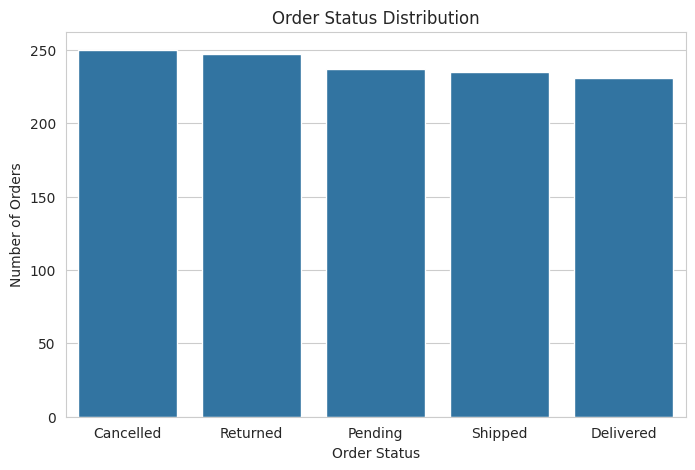


Insight:
A significant percentage of orders were either cancelled or returned,
indicating a potential issue in fulfillment or customer satisfaction.



In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='OrderStatus',
    order=df['OrderStatus'].value_counts().index
)

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')

plt.show()





print("""
Insight:
A significant percentage of orders were either cancelled or returned,
indicating a potential issue in fulfillment or customer satisfaction.
""")








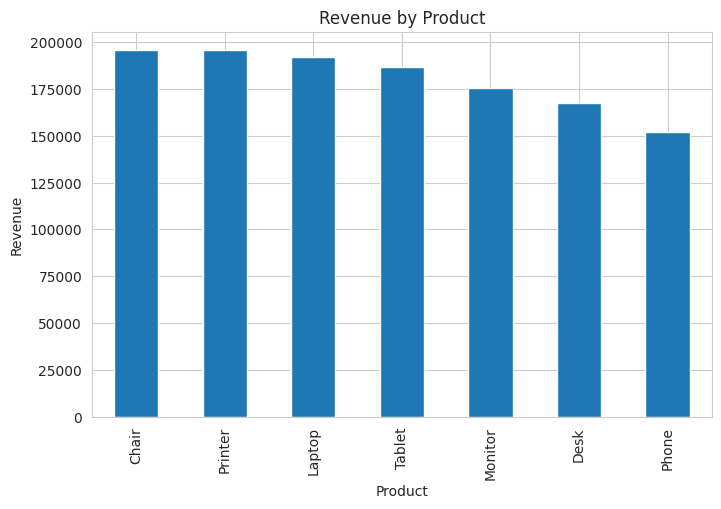


Insight:
The product category generating the highest revenue represents
the strongest contributor to business performance.



In [28]:
revenue_by_product = (
    df.groupby('Product')['TotalPrice']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

revenue_by_product.plot(kind='bar')

plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.show()




print("""
Insight:
The product category generating the highest revenue represents
the strongest contributor to business performance.
""")

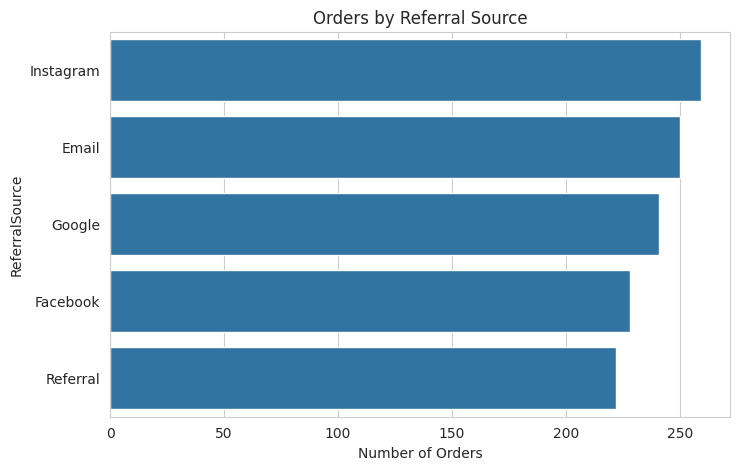


Insight:
Referral channels contribute differently to customer acquisition.
The top-performing source should receive increased marketing focus.



In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y='ReferralSource',
    order=df['ReferralSource'].value_counts().index
)

plt.title('Orders by Referral Source')
plt.xlabel('Number of Orders')

plt.show()




print("""
Insight:
Referral channels contribute differently to customer acquisition.
The top-performing source should receive increased marketing focus.
""")




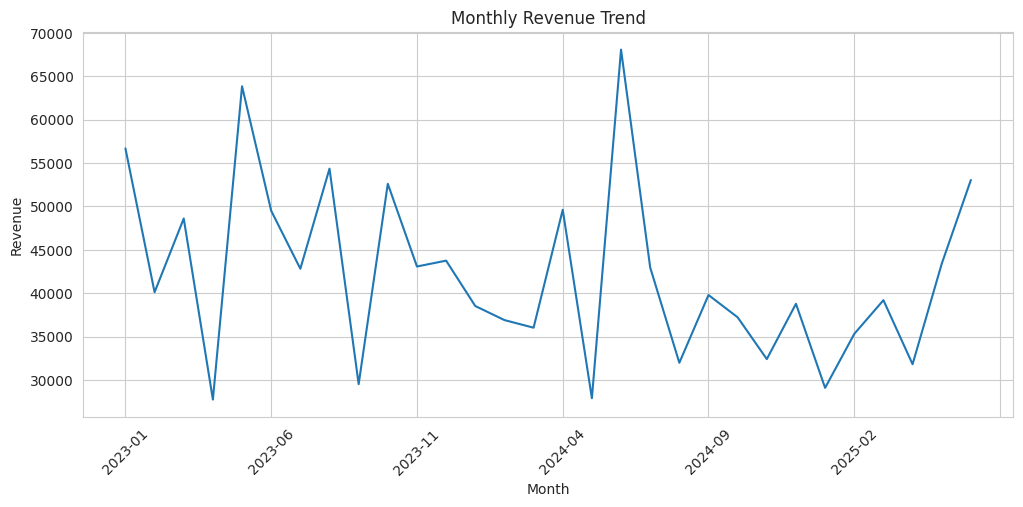


Insight:
Revenue varies across months, suggesting possible seasonal patterns
that require further investigation.



In [30]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.to_period('M').astype(str)

monthly_revenue = (
    df.groupby('Month')['TotalPrice']
      .sum()
)

plt.figure(figsize=(12,5))

monthly_revenue.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()



print("""
Insight:
Revenue varies across months, suggesting possible seasonal patterns
that require further investigation.
""")

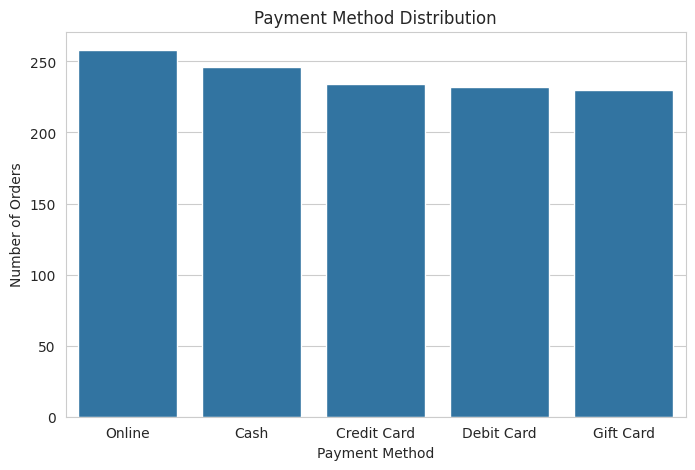


Insight:
Customer payment preferences can help optimize checkout processes
and payment service integrations.



In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='PaymentMethod',
    order=df['PaymentMethod'].value_counts().index
)

plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')

plt.show()



print("""
Insight:
Customer payment preferences can help optimize checkout processes
and payment service integrations.
""")

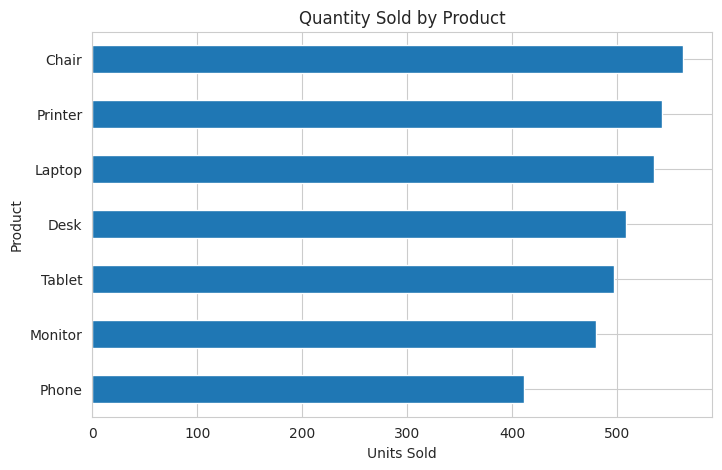


Insight:
Products with high sales volume may require inventory prioritization
and supply chain planning.



In [32]:
quantity_sold = (
    df.groupby('Product')['Quantity']
      .sum()
      .sort_values()
)

plt.figure(figsize=(8,5))

quantity_sold.plot(kind='barh')

plt.title('Quantity Sold by Product')
plt.xlabel('Units Sold')

plt.show()





print("""
Insight:
Products with high sales volume may require inventory prioritization
and supply chain planning.
""")

In [33]:
print("""
EXECUTIVE SUMMARY

1. Total Revenue exceeded $1.26 million.
2. Average Order Value was approximately $1,054.
3. Chairs generated the highest revenue.
4. Instagram drove the highest number of orders.
5. Approximately 41.4% of orders were cancelled or returned.
6. Revenue fluctuated over time with no consistent upward trend.

BUSINESS RECOMMENDATIONS

• Investigate causes of returns and cancellations.
• Increase investment in high-performing referral channels.
• Analyze seasonality in sales performance.
• Improve customer retention strategies.
• Focus inventory planning on top-performing products.
""")


EXECUTIVE SUMMARY

1. Total Revenue exceeded $1.26 million.
2. Average Order Value was approximately $1,054.
3. Chairs generated the highest revenue.
4. Instagram drove the highest number of orders.
5. Approximately 41.4% of orders were cancelled or returned.
6. Revenue fluctuated over time with no consistent upward trend.

BUSINESS RECOMMENDATIONS

• Investigate causes of returns and cancellations.
• Increase investment in high-performing referral channels.
• Analyze seasonality in sales performance.
• Improve customer retention strategies.
• Focus inventory planning on top-performing products.

